In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from textwrap import fill


oa_lsoa = pd.read_csv('../data/geofiles/lookup_oa2022_lsoa11_EW.csv')
oa_lsoa.set_index('OA21CD',inplace=True)
oa_msoa = pd.read_csv('../data/geofiles/Output_Area_to_Lower_layer_Super_Output_Area_to_Middle_layer_Super_Output_Area_to_Local_Authority_District_(December_2021)_Lookup_in_England_and_Wales_v3.csv')[["OA21CD","MSOA21CD"]].set_index('OA21CD')

imd = pd.read_csv('../data/geofiles/uk_imd2019.csv')
imd = imd[["LSOA","SOA_decile"]]
imd.columns = ['LSOA11CD','IMD']

density = pd.read_csv('../data/census_data/eng_raw_csvs/ts006.csv')
density.columns = ['OA21CD','Density']
density['Density_decile'] = pd.qcut(density['Density'],10,labels=False)
density['Density_decile'] = 10 - density['Density_decile'] #reverse the order
density.drop('Density',axis=1,inplace=True)
density.set_index('OA21CD',inplace=True)

urban_rural = pd.read_csv('../data/geofiles/Rural_Urban_Classification_(2021)_of_Output_Areas_in_EW.csv').set_index('OA21CD')

/tmp/ipykernel_94605/341406496.py:11: DtypeWarning: Columns (3,6,9) have mixed types. Specify dtype option on import or set low_memory=False.
  oa_msoa = pd.read_csv('../data/geofiles/Output_Area_to_Lower_layer_Super_Output_Area_to_Middle_layer_Super_Output_Area_to_Local_Authority_District_(December_2021)_Lookup_in_England_and_Wales_v3.csv')[["OA21CD","MSOA21CD"]].set_index('OA21CD')


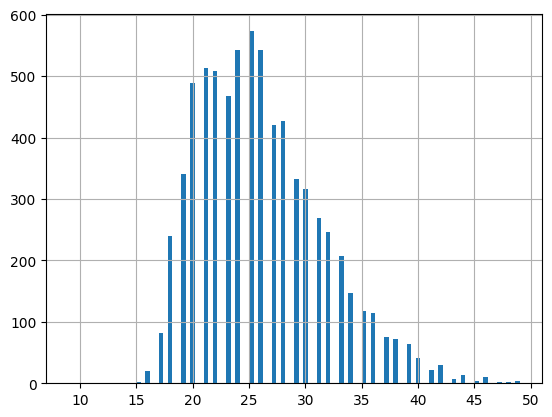

count    7264.000000
mean       26.002203
std         5.489855
min         9.000000
25%        22.000000
50%        25.000000
75%        29.000000
max        49.000000
Name: count, dtype: float64

In [2]:
#plot a hist of the number of OAs per MSOA
oa_msoa['MSOA21CD'].value_counts().hist(bins=100)
plt.show()

#get the median and max and min

oa_msoa['MSOA21CD'].value_counts().describe()

In [19]:
cleaned_data_path = "../data/census_data/engcensus_cleaned_scaled.parquet"
data = pd.read_parquet(cleaned_data_path)
# Ensure OA is a column, not just an index
data = data.reset_index()

reco_err = pd.DataFrame()
pca_reco_err = pd.DataFrame()
bottleneck_sizes = [2,4,8,16,32,64,100,128]
for bottleneck in bottleneck_sizes:
    print(f"Processing bottleneck: {bottleneck}")
    # Load reconstructed autoencoder data
    reco_path = f"../AE_outputs/engcensus_all/250epoch_scan_lin/census_geodemo__bottleneck_{bottleneck}_v1__reconstructed_outputs.csv"
    reco_data = pd.read_csv(reco_path, index_col=0)
    # Load PCA reconstruction data
    pca_path = f"../AE_outputs/engcensus_all/PCA/{bottleneck}_components.csv"
    pca_reco = pd.read_csv(pca_path, index_col=0)

    # # Compute reconstruction errors
    # ae_err = np.abs(data.set_index("OA") - reco_data).mean(axis=1).reset_index()
    # pca_err = np.abs(data.set_index("OA") - pca_reco).mean(axis=1).reset_index()
    
    # #drop ts027 columns from data using startswith
    # data = data[[col for col in data.columns if not col.startswith("ts027")]]
    # reco_data = reco_data[[col for col in reco_data.columns if not col.startswith("ts027")]]
    # pca_reco = pca_reco[[col for col in pca_reco.columns if not col.startswith("ts027")]]
    # # #compute rmse
    ae_err = np.sqrt(np.mean((data.set_index("OA") - reco_data) ** 2, axis=1)).reset_index()
    pca_err = np.sqrt(np.mean((data.set_index("OA") - pca_reco) ** 2, axis=1)).reset_index()
    # Rename columns
    ae_err = ae_err.rename(columns={0: f"reco_err_{bottleneck}"})
    pca_err = pca_err.rename(columns={0: f"pca_err_{bottleneck}"})

    #times the errors by 100 to get percentage errors
    ae_err[f"reco_err_{bottleneck}"] = ae_err[f"reco_err_{bottleneck}"] * 100
    pca_err[f"pca_err_{bottleneck}"] = pca_err[f"pca_err_{bottleneck}"] * 100
    # Normalize errors
    
    ae_err[f"reco_err_{bottleneck}_norm"] = ae_err[f"reco_err_{bottleneck}"] / ae_err[f"reco_err_{bottleneck}"].mean() * 100
    pca_err[f"pca_err_{bottleneck}_norm"] = pca_err[f"pca_err_{bottleneck}"] / pca_err[f"pca_err_{bottleneck}"].mean() * 100

    #norm by subtracting mean

    ae_err[f"reco_err_{bottleneck}_norm_sub"] = ae_err[f"reco_err_{bottleneck}"] - ae_err[f"reco_err_{bottleneck}"].mean()
    pca_err[f"pca_err_{bottleneck}_norm_sub"] = pca_err[f"pca_err_{bottleneck}"] - pca_err[f"pca_err_{bottleneck}"].mean()
    # #norm by dividing by sub and then divdiding by std
    ae_err[f"reco_err_{bottleneck}_norm_substd"] = (ae_err[f"reco_err_{bottleneck}"] - ae_err[f"reco_err_{bottleneck}"].mean()) / ae_err[f"reco_err_{bottleneck}"].std()
    pca_err[f"pca_err_{bottleneck}_norm_substd"] = (pca_err[f"pca_err_{bottleneck}"] - pca_err[f"pca_err_{bottleneck}"].mean()) / pca_err[f"pca_err_{bottleneck}"].std()

    #normed diffs againist each other

    ae_err[f"perc_diff_{bottleneck}_ae"] = (ae_err[f"reco_err_{bottleneck}"] - pca_err[f"pca_err_{bottleneck}"])/pca_err[f"pca_err_{bottleneck}"] * 100
    pca_err[f"perc_diff_{bottleneck}_pca"] = (pca_err[f"pca_err_{bottleneck}"] - ae_err[f"reco_err_{bottleneck}"])/ae_err[f"reco_err_{bottleneck}"] * 100
    
    #percentage difference
    ae_err[f"percent_diff_{bottleneck}_ave"] = (ae_err[f"reco_err_{bottleneck}"] - pca_err[f"pca_err_{bottleneck}"]) / ((ae_err[f"reco_err_{bottleneck}"] + pca_err[f"pca_err_{bottleneck}"])/2) * 100
    # #z-score errors using standard scalar
    # scaler = StandardScaler()
    # ae_err[f"reco_err_{bottleneck}_norm"] = scaler.fit_transform(ae_err[[f"reco_err_{bottleneck}"]])
    # pca_err[f"pca_err_{bottleneck}_norm"] = scaler.fit_transform(pca_err[[f"pca_err_{bottleneck}"]])
    # Merge into final DataFrames
    if reco_err.empty:
        reco_err = ae_err
        pca_reco_err = pca_err
    else:
        reco_err = reco_err.merge(ae_err, on="OA")
        pca_reco_err = pca_reco_err.merge(pca_err, on="OA")

    #print the percent difference
    perc_diff = (ae_err[f"reco_err_{bottleneck}"].mean() - pca_err[f"pca_err_{bottleneck}"].mean())/ pca_err[f"pca_err_{bottleneck}"].mean() *100
    #print the number of OAs where the AE is greater than PCA
    print(f"Number of OAs where AE is greater than PCA: {len(ae_err[ae_err[f'reco_err_{bottleneck}'] > pca_err[f'pca_err_{bottleneck}']])}")
    #print the PCAs

#rename OA to OA21CD
reco_err.rename(columns={"OA": "OA21CD"}, inplace=True)
pca_reco_err.rename(columns={"OA": "OA21CD"}, inplace=True)

Processing bottleneck: 2
Number of OAs where AE is greater than PCA: 18265
Processing bottleneck: 4
Number of OAs where AE is greater than PCA: 12578
Processing bottleneck: 8
Number of OAs where AE is greater than PCA: 5882
Processing bottleneck: 16
Number of OAs where AE is greater than PCA: 2825
Processing bottleneck: 32
Number of OAs where AE is greater than PCA: 3211
Processing bottleneck: 64
Number of OAs where AE is greater than PCA: 4268
Processing bottleneck: 100
Number of OAs where AE is greater than PCA: 13062
Processing bottleneck: 128
Number of OAs where AE is greater than PCA: 168765


In [20]:
# Load OAC data
OAC = pd.read_csv("../data/OAC/OAC_assignment.csv")
OAC = OAC[["Geography_Code", "Supergroup8", "Group", "Subgroup"]]
OAC = OAC.rename(columns={"Geography_Code": "OA21CD"})
# Load the data/OAC_cats.csv
OAC_cats = pd.read_csv("../data/OAC/OAC_cats.csv")
OAC_cats = OAC_cats[['Classification Code', 'Classification Name']]

# Make a dict out of the first 8 rows
OAC_cats_dict = OAC_cats.set_index('Classification Code')['Classification Name'].to_dict()
# Convert codes to string before mapping
OAC['Supergroup8'] = OAC['Supergroup8'].astype(str)
OAC['Supergroup_name'] = OAC['Supergroup8'].map(OAC_cats_dict)
#create a column which is Code + Name
OAC['Supergroup_codename'] = OAC['Supergroup8'] + " - " + OAC['Supergroup_name']
OAC['Group'] = OAC['Group'].astype(str)
OAC['Group_name'] = OAC['Group'].map(OAC_cats_dict)
OAC['Subgroup'] = OAC['Subgroup'].astype(str)
OAC['Subgroup_name'] = OAC['Subgroup'].map(OAC_cats_dict)

# Merge OAC data
reco_err = reco_err.merge(OAC, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(OAC, on="OA21CD", how="left")
#add urban rural
reco_err = reco_err.merge(urban_rural, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(urban_rural, on="OA21CD", how="left")
# Add density deciles
reco_err = reco_err.merge(density, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(density, on="OA21CD", how="left")
# Add LSOA
reco_err = reco_err.merge(oa_lsoa, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(oa_lsoa, on="OA21CD", how="left")
# Add MSOA
reco_err = reco_err.merge(oa_msoa, on="OA21CD", how="left")
pca_reco_err = pca_reco_err.merge(oa_msoa, on="OA21CD", how="left")
reco_err = reco_err.dropna()
# Add IMD
reco_err = reco_err.merge(imd, on="LSOA11CD", how="left").dropna()
pca_reco_err = pca_reco_err.merge(imd, on="LSOA11CD", how="left").dropna()
reco_err["IMD"] = reco_err["IMD"].astype(int)
pca_reco_err["IMD"] = pca_reco_err["IMD"].astype(int)

#check len is 188880
if len(reco_err) != 188880 or len(pca_reco_err) != 188880:
    print(f"Length of reco_err is {len(reco_err)}")
    print(f"Length of pca_reco_err is {len(pca_reco_err)}")
    raise ValueError("Dataframes do not match expected length of 188880")


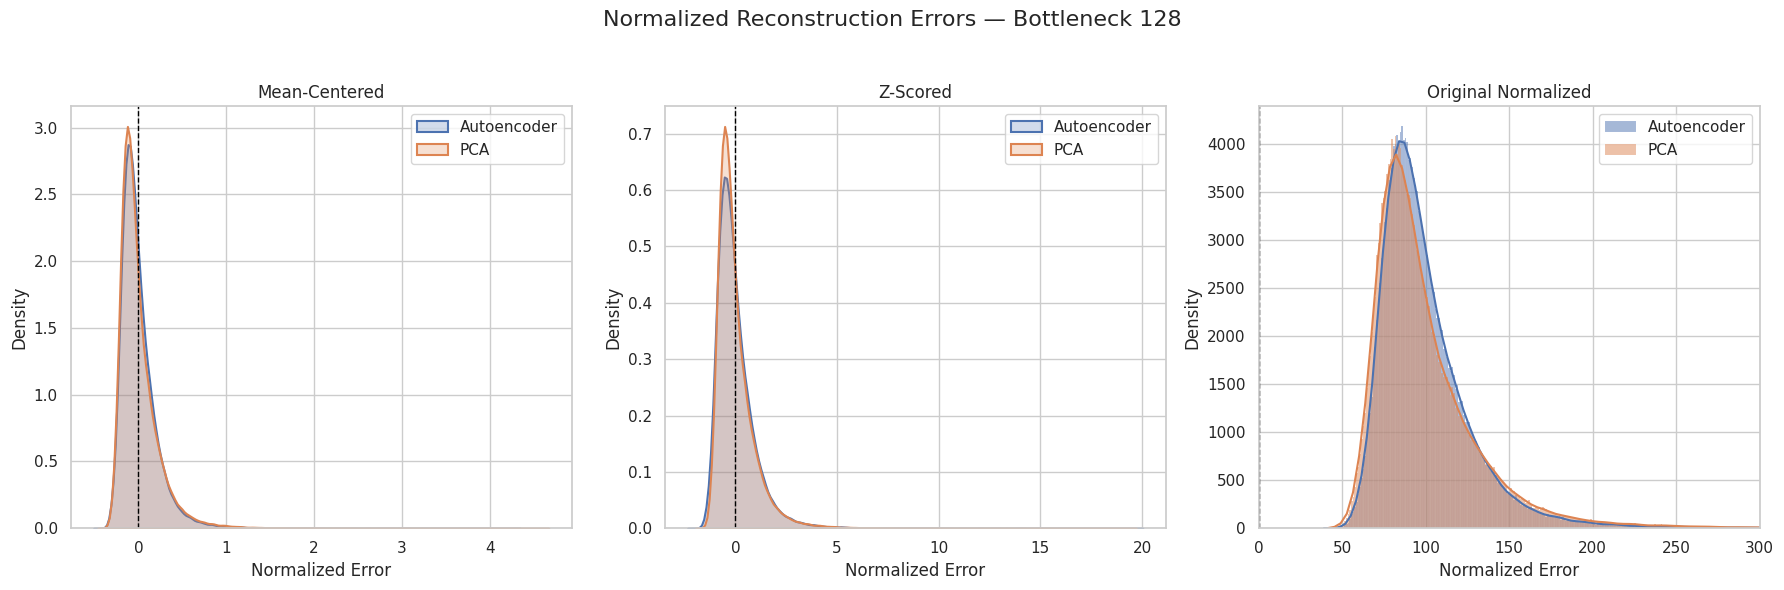

In [21]:
# Set seaborn style
sns.set(style="whitegrid")

# Create a figure with 3 side-by-side subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # Wider figure for side-by-side plots
plt.subplots_adjust(wspace=0.3)  # Space between subplots

# --- Subplot 1: KDE of normalized errors (mean-subtracted) ---
sns.kdeplot(
    data=ae_err, 
    x=f"reco_err_{bottleneck}_norm_sub", 
    label="Autoencoder", 
    fill=True, 
    linewidth=1.5,
    ax=axes[0]
)
sns.kdeplot(
    data=pca_err, 
    x=f"pca_err_{bottleneck}_norm_sub", 
    label="PCA", 
    fill=True, 
    linewidth=1.5,
    ax=axes[0]
)
axes[0].axvline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Mean-Centered")
axes[0].set_xlabel("Normalized Error")
axes[0].set_ylabel("Density")
axes[0].legend()

# --- Subplot 2: KDE of normalized errors (z-scored) ---
sns.kdeplot(
    data=ae_err, 
    x=f"reco_err_{bottleneck}_norm_substd", 
    label="Autoencoder", 
    fill=True, 
    linewidth=1.5,
    ax=axes[1]
)
sns.kdeplot(
    data=pca_err, 
    x=f"pca_err_{bottleneck}_norm_substd",
    label="PCA", 
    fill=True, 
    linewidth=1.5,
    ax=axes[1]
)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Z-Scored")
axes[1].set_xlabel("Normalized Error")
axes[1].set_ylabel("Density")
axes[1].legend()

# --- Subplot 3: Histogram of original normalized errors ---
bins = np.linspace(0, 300, 300)
sns.histplot(
    data=ae_err, 
    x=f"reco_err_{bottleneck}_norm", 
    label="Autoencoder",
    bins=bins,
    kde=True,
    ax=axes[2]
)
sns.histplot(
    data=pca_err, 
    x=f"pca_err_{bottleneck}_norm", 
    label="PCA",
    bins=bins,
    kde=True,
    ax=axes[2]
)
axes[2].axvline(0, color="black", linestyle="--", linewidth=1)
axes[2].set_xlim(0, 300)
axes[2].set_title("Original Normalized")
axes[2].set_xlabel("Normalized Error")
axes[2].set_ylabel("Density")
axes[2].legend()

# Final layout and display
fig.suptitle(f"Normalized Reconstruction Errors — Bottleneck {bottleneck}", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [22]:
from torch import norm


def prepare_grouped_data(df1, df2, group_col, bottleneck, norm=False):
    """Merge two datasets and compute mean reconstruction error for each group."""

    if norm:
        ae_col = f"reco_err_{bottleneck}_norm"
        pca_col = f"pca_err_{bottleneck}_norm"
    else:
        ae_col = f"reco_err_{bottleneck}"
        pca_col = f"pca_err_{bottleneck}"
    
    grouped_1 = df1.groupby(group_col)[ae_col].mean().reset_index()
    grouped_2 = df2.groupby(group_col)[pca_col].mean().reset_index()
    
    grouped = grouped_1.merge(grouped_2, on=group_col)
    grouped.rename(columns={ae_col: "AE", pca_col: "PCA"}, inplace=True)
    
    grouped_melted = grouped.melt(id_vars=[group_col], var_name="Error Type", value_name="Mean Reco Error")
    return grouped, grouped_melted


def plot_combined_chart(df1, df2, group_col, xlabel, title_prefix, palette, bottleneck, wrapped_labels=False):
    grouped, grouped_melted = prepare_grouped_data(df1, df2, group_col, bottleneck)
    grouped["Error Difference"] = grouped["AE"] - grouped["PCA"]
    grouped["Perc_Error_Change"] = (grouped["AE"] - grouped["PCA"]) / grouped["PCA"] * 100
    fig, axes = plt.subplots(2, 1, figsize=(8, 7), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

    # Top: Side-by-side bar chart
    sns.barplot(ax=axes[0], x=group_col, y="Mean Reco Error", hue="Error Type", data=grouped_melted, palette=palette)
    axes[0].set_xlabel("")
    axes[0].set_ylabel("% of Mean Reconstruction Error")
    axes[0].set_title(f"{title_prefix} (Bottleneck {bottleneck})")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].legend(title="Error Type", frameon=False)

    # Bottom: Error difference
    if norm:
        sns.barplot(ax=axes[1], x=group_col, y="Error Difference", data=grouped, color="darkblue")
    else:
        sns.barplot(ax=axes[1], x=group_col, y="Perc_Error_Change", data=grouped, color="darkblue")
    axes[1].axhline(grouped["Perc_Error_Change"].mean(), color="red", linestyle="--")
    axes[1].set_xlabel(xlabel)
    axes[1].set_ylabel("Difference (AE - PCA) [%]")
    axes[1].tick_params(axis='x', rotation=30)

    if wrapped_labels:
        axes[0].set_xticklabels([fill(label, width=10) for label in grouped[group_col]])
        axes[1].set_xticklabels([fill(label, width=10) for label in grouped[group_col]])

    plt.tight_layout()
    plt.savefig(f"plots/comparison_{xlabel}_bottleneck_{bottleneck}.png", dpi=300)
    plt.show()

def plot_side_by_side_charts(df1, df2, group_col1, group_col2, xlabel1, xlabel2, title_prefix, palette, bottleneck, norm=False, rotation=45, wrapped_labels=False, print_means=False):
    """Creates a figure with two side-by-side subplots for IMD and Density Decile, with optional mean value printing."""
    
    grouped1, grouped_melted1 = prepare_grouped_data(df1, df2, group_col1, bottleneck, norm=norm)
    grouped2, grouped_melted2 = prepare_grouped_data(df1, df2, group_col2, bottleneck, norm=norm)
    grouped1["Error Difference"] = grouped1["AE"] - grouped1["PCA"]
    grouped1["Perc_Error_Change"] = (grouped1["AE"] - grouped1["PCA"]) / grouped1["PCA"] * 100
    grouped2["Error Difference"] = grouped2["AE"] - grouped2["PCA"]
    grouped2["Perc_Error_Change"] = (grouped2["AE"] - grouped2["PCA"]) / grouped2["PCA"] * 100

    if print_means:
        def print_summary(grouped_melted, group_col, label):
            means = grouped_melted.groupby([group_col, "Error Type"])["Mean Reco Error"].mean().unstack()
            print(f"\n=== Mean Reconstruction Error by Group ({label}) ===")
            print(means)

            if grouped_melted[group_col].dtype.name == "category":
                levels = grouped_melted[group_col].cat.categories
            else:
                levels = sorted(grouped_melted[group_col].unique())

            if len(levels) >= 2:
                first, last = levels[0], levels[-1]
                print(f"\n--- Percentage Increase in Error ({label}): {last} → {first} ---")
                for error_type in means.columns:
                    first_val = means.loc[first, error_type]
                    last_val = means.loc[last, error_type]
                    perc_diff = ((first_val - last_val) / last_val) * 100
                    print(f"{error_type}: {perc_diff:.2f}%")


        print_summary(grouped_melted1, group_col1, xlabel1)
        print_summary(grouped_melted2, group_col2, xlabel2)

    
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), gridspec_kw={'height_ratios': [3, 1]}, sharex='col')
    
    sns.barplot(ax=axes[0, 0], x=group_col1, y="Mean Reco Error", hue="Error Type", data=grouped_melted1, palette=palette)
    axes[0, 0].set_xlabel("")
    axes[0, 0].set_ylabel("% of Mean Reconstruction Error" if norm else "Mean Reconstruction Error (RMSE)")
    axes[0, 0].set_title(f"{title_prefix} by {xlabel1}")
    axes[0, 0].tick_params(axis='x', rotation=rotation)
    axes[0, 0].legend(title="Error Type", frameon=False)
    
    sns.barplot(ax=axes[0, 1], x=group_col2, y="Mean Reco Error", hue="Error Type", data=grouped_melted2, palette=palette)
    axes[0, 1].set_xlabel("")
    axes[0, 1].set_ylabel("")
    axes[0, 1].set_title(f"{title_prefix} by {xlabel2}")
    axes[0, 1].tick_params(axis='x', rotation=rotation)
    axes[0, 1].legend(title="Error Type", frameon=False)

    if norm:
        sns.barplot(ax=axes[1, 0], x=group_col1, y="Error Difference", data=grouped1, color="darkblue")
        axes[1, 0].axhline(0, color="red", linestyle="--")
        axes[1, 0].set_ylabel("Difference (AE - PCA) [%]")
    else:
        sns.barplot(ax=axes[1, 0], x=group_col1, y="Perc_Error_Change", data=grouped1, color="darkblue")
        axes[1, 0].axhline(grouped1["Perc_Error_Change"].mean(), color="red", linestyle="--")
        axes[1, 0].set_ylabel("(AE - PCA)/PCA [%]")
    axes[1, 0].set_xlabel(xlabel1)
    axes[1, 0].tick_params(axis='x', rotation=rotation)
    
    if norm:
        sns.barplot(ax=axes[1, 1], x=group_col2, y="Error Difference", data=grouped2, color="darkblue")
        axes[1, 1].axhline(0, color="red", linestyle="--")
        axes[1, 1].set_ylabel("Difference (AE - PCA) [%]")
    else:
        sns.barplot(ax=axes[1, 1], x=group_col2, y="Perc_Error_Change", data=grouped2, color="darkblue")
        axes[1, 1].axhline(grouped2["Perc_Error_Change"].mean(), color="red", linestyle="--")
        axes[1, 1].set_ylabel("(AE - PCA)/PCA [%]")
    axes[1, 1].set_xlabel(xlabel2)
    axes[1, 1].tick_params(axis='x', rotation=0)

    if wrapped_labels:
        axes[0, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
        axes[1, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
        axes[0, 1].set_xticklabels([fill(label, width=21) for label in grouped2[group_col2]])
        axes[1, 1].set_xticklabels([fill(label, width=21) for label in grouped2[group_col2]])
    
    plt.tight_layout()
    plt.savefig(f"plots/comparison_{xlabel1}_{xlabel2}_bottleneck_{bottleneck}.png", dpi=300)
    plt.show()


Processing bottleneck: 100
##################################################
##################################################
##################################################

=== Mean Reconstruction Error by Group (IMD Decile) ===
Error Type        AE       PCA
IMD                           
1           0.902292  1.021146
2           0.869339  0.988226
3           0.854406  0.970913
4           0.825822  0.938972
5           0.798797  0.899005
6           0.782260  0.878930
7           0.751787  0.836593
8           0.738848  0.823429
9           0.722552  0.801474
10          0.697128  0.774880

--- Percentage Increase in Error (IMD Decile): 10 → 1 ---
AE: 29.43%
PCA: 31.78%

=== Mean Reconstruction Error by Group (Density Decile) ===
Error Type            AE       PCA
Density_decile                    
1               1.046494  1.225550
2               0.888851  1.008057
3               0.801372  0.893756
4               0.762177  0.846445
5               0.743714  0.824573
6  

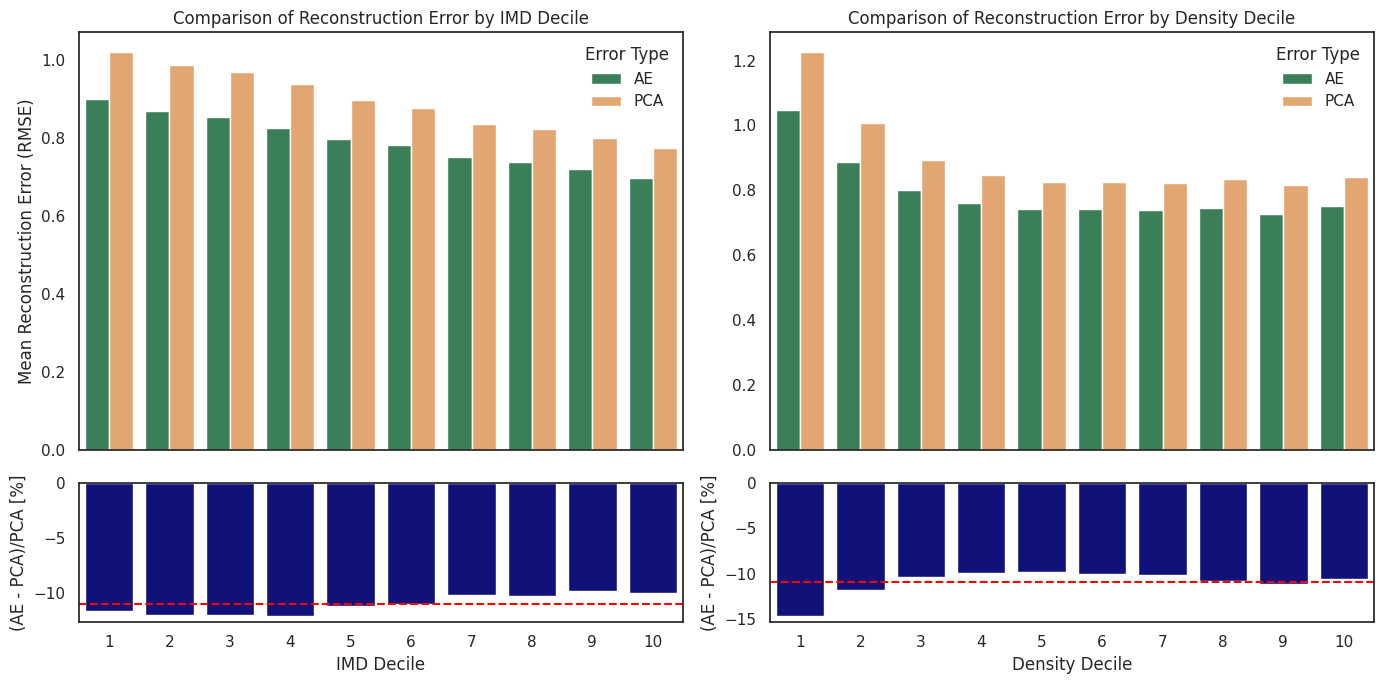

/tmp/ipykernel_94605/2314457434.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
/tmp/ipykernel_94605/2314457434.py:131: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
/tmp/ipykernel_94605/2314457434.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels([fill(label, width=21) for label in grouped2[group_col2]])
/tmp/ipykernel_94605/2314457434.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels([fill(label, width=21) for label in

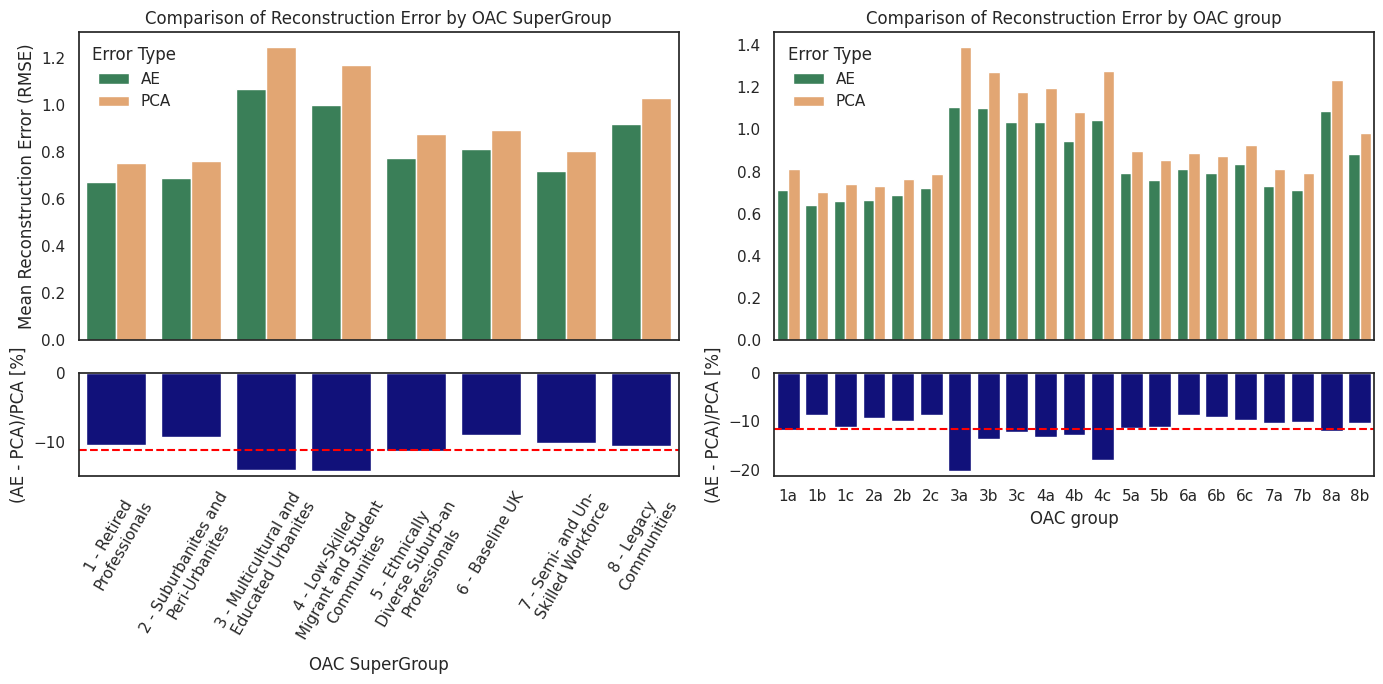

Processing bottleneck: 100
##################################################
##################################################
##################################################


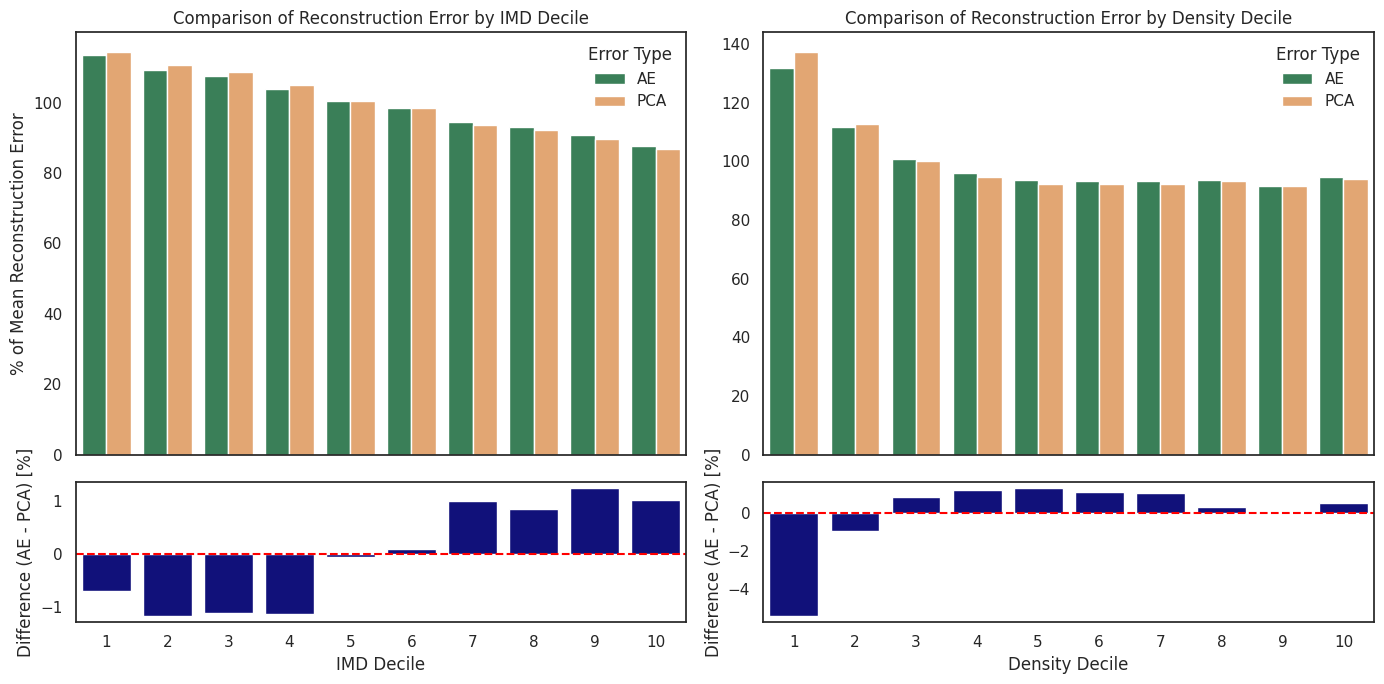

/tmp/ipykernel_94605/2314457434.py:130: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
/tmp/ipykernel_94605/2314457434.py:131: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 0].set_xticklabels([fill(label, width=21) for label in grouped1[group_col1]])
/tmp/ipykernel_94605/2314457434.py:132: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 1].set_xticklabels([fill(label, width=21) for label in grouped2[group_col2]])
/tmp/ipykernel_94605/2314457434.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels([fill(label, width=21) for label in

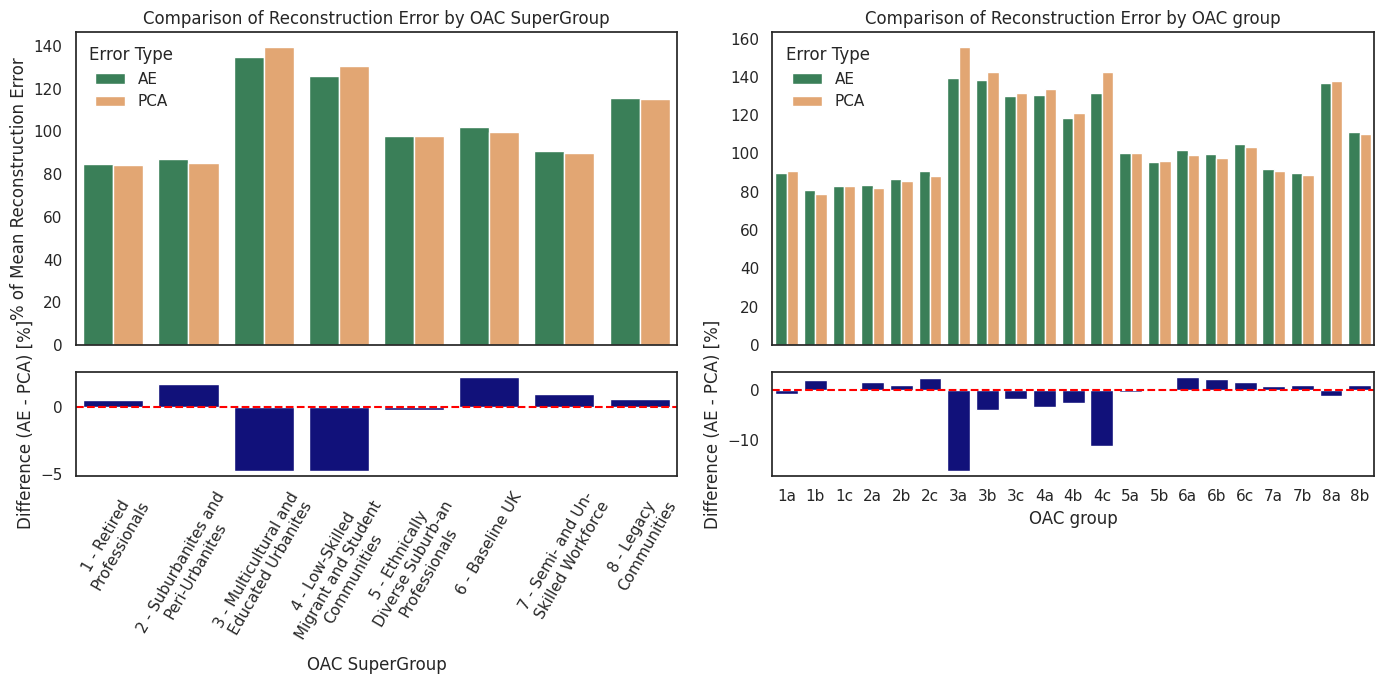

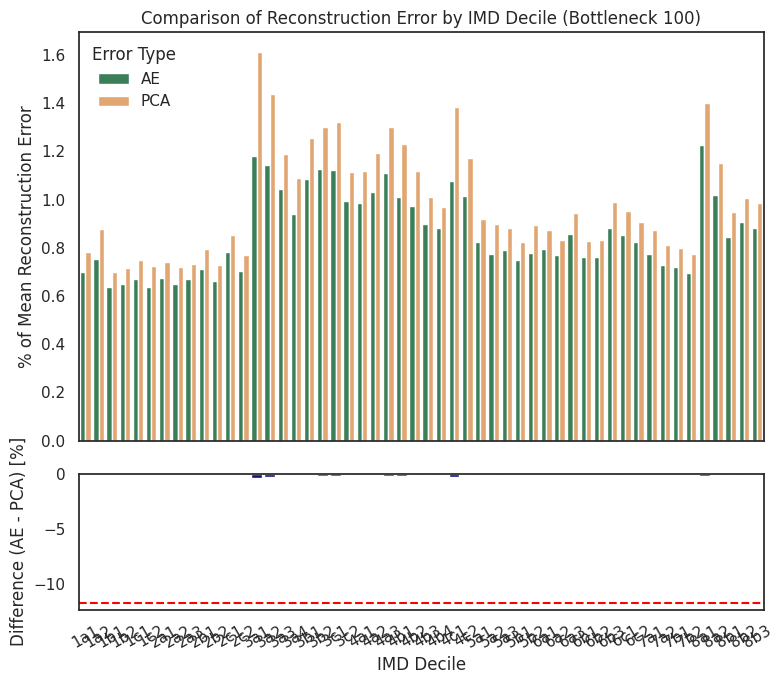

In [25]:
# Set seaborn style
sns.set(style="white")
#
# Color palette
palette = {
    "AE": "seagreen",
    "PCA": "sandybrown"
}

for bottleneck in bottleneck_sizes:
    print(f"Processing bottleneck: {bottleneck}")
    #print line of hashes and big gap
    print("#" * 50)
    print("#" * 50)
    print("#" * 50)
    plot_side_by_side_charts(
        reco_err, 
        pca_reco_err, 
        "IMD", 
        "Density_decile", 
        "IMD Decile", 
        "Density Decile", 
        "Comparison of Reconstruction Error", 
        palette,
        bottleneck=bottleneck,
        rotation=0,
        print_means=True
    )
    
    # plot_side_by_side_charts(
    #     reco_err, 
    #     pca_reco_err, 
    #     "RUC21NM", 
    #     "Urban_rural_flag", 
    #     "Urban-Rural Classification", 
    #     "Urban-Rural", 
    #     "Comparison of Reconstruction Error", 
    #     palette,
    #     bottleneck=bottleneck  
    # )

    # # Keep the separate Supergroup plot
    # plot_combined_chart(reco_err, pca_reco_err, "Supergroup_name", "Supergroup", "Comparison of Reconstruction Error by OAC Supergroup", palette, bottleneck=bottleneck, wrapped_labels=True)

    plot_side_by_side_charts(
        reco_err, 
        pca_reco_err, 
        "Supergroup_codename", 
        "Group", 
        "OAC SuperGroup", 
        "OAC group", 
        "Comparison of Reconstruction Error", 
        palette,
        bottleneck=bottleneck, 
        rotation=60,
        wrapped_labels=True
    )
    
    # plot_side_by_side_charts(
    #     reco_err, 
    #     pca_reco_err, 
    #     "Supergroup_name", 
    #     "Group_name", 
    #     "OAC SuperGroup", 
    #     "OAC group", 
    #     "Comparison of Reconstruction Error", 
    #     palette,
    #     bottleneck=bottleneck, 
    #     rotation=90
    # )

    # plot_side_by_side_charts(
    #     reco_err, 
    #     pca_reco_err, 
    #     "Group", 
    #     "Subgroup", 
    #     "OAC SuperGroup", 
    #     "OAC group", 
    #     "Comparison of Reconstruction Error", 
    #     palette,
    #     bottleneck=bottleneck, 
    #     rotation=90
    # )
    # plot_side_by_side_charts(
    #     reco_err, 
    #     pca_reco_err, 
    #     "Group_name", 
    #     "Subgroup_name", 
    #     "OAC SuperGroup", 
    #     "OAC group", 
    #     "Comparison of Reconstruction Error", 
    #     palette,
    #     bottleneck=bottleneck, 
    #     rotation=90
    # )


bottleneck_sizes = [100]
for bottleneck in bottleneck_sizes:
    print(f"Processing bottleneck: {bottleneck}")
    #print line of hashes and big gap
    print("#" * 50)
    print("#" * 50)
    print("#" * 50)
    plot_side_by_side_charts(
        reco_err, 
        pca_reco_err, 
        "IMD", 
        "Density_decile", 
        "IMD Decile", 
        "Density Decile", 
        "Comparison of Reconstruction Error", 
        palette,
        bottleneck=bottleneck,
        rotation=0,
        norm=True
    )
    
    plot_side_by_side_charts(
        reco_err, 
        pca_reco_err, 
        "Supergroup_codename", 
        "Group", 
        "OAC SuperGroup", 
        "OAC group", 
        "Comparison of Reconstruction Error", 
        palette,
        bottleneck=bottleneck, 
        rotation=60,
        wrapped_labels=True,
        norm=True
    )


    plot_combined_chart(
        reco_err, 
        pca_reco_err, 
        "Subgroup", 
        "IMD Decile", 
        "Comparison of Reconstruction Error by IMD Decile", 
        palette, 
        bottleneck=bottleneck,
    )

In [33]:
reco_err

,OA21CD,reco_err_2,reco_err_2_norm,reco_err_2_norm_sub,reco_err_2_norm_substd,perc_diff_2_ae,percent_diff_2_ave,reco_err_4,reco_err_4_norm,reco_err_4_norm_sub,...,Group_name,Subgroup_name,RUC21CD,RUC21NM,Urban_rural_flag,ObjectId,Density_decile,LSOA11CD,MSOA21CD,IMD
0,E00000001,9.147359,241.163772,5.354352,4.841946,-7.150590,-7.415724,6.841639,219.875701,3.730045,...,Diverse Educated Urban Singles,Career Progression,UN1,Urban: Nearer to a major town or city,Urban,201,1,E01000001,E02000001,9
1,E00000003,7.589612,200.094838,3.796605,3.433274,-12.455423,-13.282627,6.241171,200.577954,3.129577,...,Diverse Educated Urban Singles,Career Progression,UN1,Urban: Nearer to a major town or city,Urban,202,1,E01000001,E02000001,9
2,E00000005,6.676951,176.033159,2.883943,2.607953,-24.054977,-27.343742,5.183106,166.573978,2.071512,...,Diverse Educated Urban Singles,Centrally Located Professionals,UN1,Urban: Nearer to a major town or city,Urban,203,1,E01000001,E02000001,9
3,E00000007,3.856122,101.663981,0.063115,0.057075,-56.437522,-78.624335,3.050173,98.026072,-0.061421,...,Diverse Educated Urban Singles,Centrally Located Professionals,UN1,Urban: Nearer to a major town or city,Urban,204,8,E01000001,E02000001,9
4,E00000010,7.813864,206.007094,4.020857,3.636065,-19.313299,-21.377665,5.074229,163.074900,1.962635,...,Ethnically Diverse Young Families,Private Rental Ethnic Minority Families,UN1,Urban: Nearer to a major town or city,Urban,205,1,E01000003,E02000001,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188875,W00010693,5.514564,145.387643,1.721557,1.556806,-65.478630,-97.350525,4.417696,141.975333,1.306102,...,Student Living and Professional Footholds,University Centric,UF1,Urban: Further from a major town or city,Urban,188876,4,W01000062,W02000010,5
188876,W00010694,4.573142,120.567705,0.780135,0.705477,-3.536213,-3.599862,2.575880,82.783289,-0.535714,...,Small Town Suburbia,Younger Established Suburban Communities,UF1,Urban: Further from a major town or city,Urban,188877,8,W01000645,W02000147,7
188877,W00010695,3.026985,79.804363,-0.766022,-0.692714,-57.914537,-81.520707,3.013618,96.851279,-0.097975,...,Small Town Suburbia,Younger Established Suburban Communities,UN1,Urban: Nearer to a major town or city,Urban,188878,9,W01000664,W02000157,6
188878,W00010696,4.762761,125.566887,0.969754,0.876949,-20.723240,-23.118713,2.787664,89.589588,-0.323930,...,Rural Amenity,Rural Mix,UN1,Urban: Nearer to a major town or city,Urban,188879,9,W01001923,W02000167,3


In [37]:
#delete merged df
del merged

In [38]:
# Load OA boundaries
oa_gdf = gpd.read_parquet("../data/geofiles/oabounds_2021approx.parquet")[["OA", "geometry"]].rename(columns={"OA": "OA21CD"})

# Merge while keeping suffixes on duplicates
merged = reco_err.merge(pca_reco_err, on="OA21CD", suffixes=("", "_pca"))
# Drop duplicated columns that came from pca_reco_err and already exist in reco_err
merged = merged[[col for col in merged.columns if not col.endswith("_pca") or col.startswith("pca_err")]]

# Merge with OA boundaries
merged = oa_gdf.merge(merged, on="OA21CD", how="right")

# Add computed columns
for b in bottleneck_sizes:
    merged[f"error_diff_ae_pca_{b}"] = merged[f"reco_err_{b}_norm"] - merged[f"pca_err_{b}_norm"]
    merged[f"AE_<_PCA_{b}"] = merged[f"reco_err_{b}_norm"] < merged[f"pca_err_{b}_norm"]
    merged[f"perc_diff_{b}"] = (merged[f"reco_err_{b}"] - merged[f"pca_err_{b}"]) / merged[f"pca_err_{b}"] * 100


#set OA as index and round all columns to 5 dep
merged.set_index("OA21CD", inplace=True)
# Round all columns to 5 decimal places
merged = merged.round(5)
# Save to Parquet
merged.to_parquet("../data/outputs/maps/error_diff_by_OA.parquet")


In [39]:
bottleneck_sizes

[100]

In [40]:
merged

,geometry,reco_err_2,reco_err_2_norm,reco_err_2_norm_sub,reco_err_2_norm_substd,perc_diff_2_ae,percent_diff_2_ave,reco_err_4,reco_err_4_norm,reco_err_4_norm_sub,...,pca_err_100_norm,pca_err_100_norm_sub,pca_err_100_norm_substd,pca_err_128,pca_err_128_norm,pca_err_128_norm_sub,pca_err_128_norm_substd,error_diff_ae_pca_100,AE_<_PCA_100,perc_diff_100
OA21CD,,,,,,,,,,,,,,,,,,,,,
E00000001,"POLYGON ((532303.125 181877.594, 532303.492 18...",9.14736,241.16377,5.35435,4.84195,-7.15059,-7.41572,6.84164,219.87570,3.73004,...,171.03979,0.63510,2.10381,1.25905,184.20180,0.57553,2.42869,37.36261,False,8.32882
E00000003,"POLYGON ((532198.818 181863.087, 532213.954 18...",7.58961,200.09484,3.79660,3.43327,-12.45542,-13.28263,6.24117,200.57795,3.12958,...,139.84047,0.35617,1.17986,0.95936,140.35594,0.27584,1.16402,17.53659,False,0.05689
E00000005,"POLYGON ((532178.979 181764.041, 532219.161 18...",6.67695,176.03316,2.88394,2.60795,-24.05498,-27.34374,5.18311,166.57398,2.07151,...,193.88428,0.83933,2.78034,1.19406,174.69390,0.51055,2.15445,-4.16704,True,-13.00333
E00000007,"POLYGON ((532160 181671, 532275.938 181637.75,...",3.85612,101.66398,0.06311,0.05707,-56.43752,-78.62433,3.05017,98.02607,-0.06142,...,176.05091,0.67989,2.25221,1.28947,188.65221,0.60595,2.55706,2.56185,False,-9.79873
E00000010,"POLYGON ((532127.958 182133.192, 532089.264 18...",7.81386,206.00709,4.02086,3.63607,-19.31330,-21.37766,5.07423,163.07490,1.96263,...,158.94029,0.52693,1.74549,1.23013,179.97055,0.54661,2.30665,2.96265,False,-9.43525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
W00010693,"POLYGON ((258000.635 371797.895, 258087.308 37...",5.51456,145.38764,1.72156,1.55681,-65.47863,-97.35052,4.41770,141.97533,1.30610,...,164.16351,0.57362,1.90017,1.17459,171.84490,0.49107,2.07227,6.36583,False,-7.64489
W00010694,"POLYGON ((240288.25 220817.041, 240410.529 220...",4.57314,120.56770,0.78013,0.70548,-3.53621,-3.59986,2.57588,82.78329,-0.53571,...,76.07719,-0.21387,-0.70846,0.53039,77.59659,-0.15313,-0.64620,2.03883,False,-8.70981
W00010695,"POLYGON ((256746.533 213201.63, 256616.094 213...",3.02699,79.80436,-0.76602,-0.69271,-57.91454,-81.52071,3.01362,96.85128,-0.09798,...,105.10103,0.04560,0.15106,0.71181,104.13996,0.02830,0.11941,11.29721,False,-1.53590


In [32]:
#load MSOA boundaries
msoa_gdf=gpd.read_file("../data/geofiles/Middle_layer_Super_Output_Areas_(December_2021)_Boundaries_EW_BFE_(V8)_and_RUC")[["MSOA21CD","geometry"]]

#drop all columns that are not reco_err or pca_err (only keep those that start with reco_err or pca_err)
merged = merged[[col for col in merged.columns if col.startswith("reco_err") or col.startswith("pca_err") or col == "MSOA21CD"]]
msoa = merged.groupby("MSOA21CD").mean().reset_index()
#techincally this is not correct as we are averaging after the normalization, but it is clos

# Add computed columns
for b in bottleneck_sizes:
    msoa[f"error_diff_ae_pca_{b}"] = msoa[f"reco_err_{b}_norm"] - msoa[f"pca_err_{b}_norm"]
    msoa[f"AE_<_PCA_{b}"] = msoa[f"reco_err_{b}_norm"] < msoa[f"pca_err_{b}_norm"]
    msoa[f"perc_diff_{b}"] = (msoa[f"reco_err_{b}"] - msoa[f"pca_err_{b}"]) / msoa[f"pca_err_{b}"] * 100
    msoa[f"sub_perc_diff_{b}"] = (msoa[f"reco_err_{b}"] - msoa[f"pca_err_{b}"])
#merge the MSOA boundaries
msoa = msoa_gdf.merge(msoa, on="MSOA21CD", how="right")

#save to parquet
msoa.to_parquet("../data/outputs/maps/error_diff_by_MSOA.parquet")


In [ ]:
# Filter for negative values only
neg_values = msoa[msoa["perc_diff_100"] < 0]["perc_diff_100"]
print(len(msoa)-len(neg_values),"out of",len(msoa),"are negative")
# Calculate quantile breaks (e.g., 4 breaks = quartiles)
quantiles = neg_values.quantile([0, 0.2, 0.4, 0.6, 0.8, 1])
#6 intervals
# s
print(quantiles)


8 out of 7264 are negative
0.0000   -55.718602
0.1667   -12.872506
0.3333   -10.433551
0.5000    -9.207476
0.6667    -8.217768
0.8333    -7.172739
1.0000    -0.006678
Name: perc_diff_100, dtype: float64


In [29]:
# Filter for negative values only
neg_values = msoa[msoa["sub_perc_diff_100"] < 0]["sub_perc_diff_100"]
print(len(msoa)-len(neg_values),"out of",len(msoa),"are negative")
# Calculate quantile breaks (e.g., 4 breaks = quartiles)
quantiles = neg_values.quantile([0, 0.2, 0.4, 0.6, 0.8, 1])
print(quantiles)


8 out of 7264 are negative
0.0   -1.589109
0.2   -0.118233
0.4   -0.082682
0.6   -0.068556
0.8   -0.057023
1.0   -0.000278
Name: sub_perc_diff_100, dtype: float64
